## PHASE 1

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [ ]:
df = pd.read_csv("zomato.csv")
print(df.head())
print(df.shape)
print(df.tail())
print(df.dtypes)
print(df.columns)
print(df.describe())

  Restaurant_ID       City     Cuisines  Average_Cost_for_two  \
0         ZOM_1       Pune    Fast Food                 220.0   
1         ZOM_2  Hyderabad    Fast Food                1020.0   
2         ZOM_3  Bangalore  Continental                1120.0   
3         ZOM_4  Hyderabad      Chinese                1440.0   
4         ZOM_5  Hyderabad      Chinese                1370.0   

  Has_Online_delivery  Aggregate_Rating  Votes  Price_Range  
0                 Yes               NaN   3690            1  
1                  No               2.2   4043            2  
2                 Yes               2.8   2485            1  
3                  No               3.8   3316            4  
4                  No               NaN   1838            2  
(20000, 8)
      Restaurant_ID       City      Cuisines  Average_Cost_for_two  \
19995     ZOM_19996     Mumbai       Chinese                 870.0   
19996     ZOM_19997  Bangalore       Italian                 550.0   
19997     ZOM_19

In [ ]:
#Mean gives the overall average cost, median represents the typical middle-market price,
#mode shows the most common pricing level, and
#standard deviation measures how much pricing varies across restaurants.
mean_cost = df['Average_Cost_for_two'].mean()
median_cost = df['Average_Cost_for_two'].median()
mode_cost = df['Average_Cost_for_two'].mode()[0]
standard_deviation = df['Average_Cost_for_two'].std()

print("Mean:", mean_cost)
print("Median:", median_cost)
print("Mode:", mode_cost)
print(f"Standard Deviation : {standard_deviation}")
#By comparing mean and median, we can identify whether the cost distribution is skewed.\
# If the mean is greater than the median, it indicates a right-skewed distribution caused by a few high-cost restaurants

Mean: 835.508
Median: 670.0
Mode: 410.0
Standard Deviation : 1448.141742945543


The standard deviation of the average cost for two is relatively high compared to the mean. This indicates significant price variation across restaurants, meaning the market contains both low-cost and premium establishments.

In [ ]:
top_cuisines = df['Cuisines'].value_counts().head(5)
print(top_cuisines)


min_price = df['Average_Cost_for_two'].min()
max_price = df['Average_Cost_for_two'].max()

print("Minimum Cost for Two:", min_price)
print("Maximum Cost for Two:", max_price)

Cuisines
Fast Food       3443
Continental     3372
Italian         3333
Chinese         3296
South Indian    3285
Name: count, dtype: int64
Minimum Cost for Two: 70.0
Maximum Cost for Two: 50000.0


## PHASE 2

In [ ]:
print(f"Duplicates before removal: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True) #inplace=True modifies df directly
print(f"Duplicates after removal: {df.duplicated().sum()}")

Duplicates before removal: 0
Duplicates after removal: 0


In [ ]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
Restaurant_ID              0
City                       0
Cuisines                   0
Average_Cost_for_two       0
Has_Online_delivery        0
Aggregate_Rating        1200
Votes                      0
Price_Range                0
dtype: int64


In [ ]:
city_mean = df.groupby('City')['Aggregate_Rating'].transform('mean')
df['Aggregate_Rating'] = df['Aggregate_Rating'].fillna(city_mean)


print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
Restaurant_ID           0
City                    0
Cuisines                0
Average_Cost_for_two    0
Has_Online_delivery     0
Aggregate_Rating        0
Votes                   0
Price_Range             0
dtype: int64


In [ ]:
df['Has_Online_delivery'] = df['Has_Online_delivery'].map({'Yes': 1, 'No': 0})

print("\nEncoded Has_Online_delivery:")
print(df['Has_Online_delivery'].head())


Encoded Has_Online_delivery:
0    1
1    0
2    1
3    0
4    0
Name: Has_Online_delivery, dtype: int64


In [ ]:
min_cost = df['Average_Cost_for_two'].min()
max_cost = df['Average_Cost_for_two'].max()

df['Average_Cost_for_two'] = (
    df['Average_Cost_for_two'] - min_cost
) / (max_cost - min_cost)

print("\nNormalized Cost Preview:")
print(df['Average_Cost_for_two'].head())


Normalized Cost Preview:
0    0.003004
1    0.019027
2    0.021029
3    0.027438
4    0.026036
Name: Average_Cost_for_two, dtype: float64


In [ ]:
print(df.head())
print("\nPhase 2 Completed Successfully...")

  Restaurant_ID       City     Cuisines  Average_Cost_for_two  \
0         ZOM_1       Pune    Fast Food              0.003004   
1         ZOM_2  Hyderabad    Fast Food              0.019027   
2         ZOM_3  Bangalore  Continental              0.021029   
3         ZOM_4  Hyderabad      Chinese              0.027438   
4         ZOM_5  Hyderabad      Chinese              0.026036   

   Has_Online_delivery  Aggregate_Rating  Votes  Price_Range  
0                    1          3.180351   3690            1  
1                    0          2.200000   4043            2  
2                    1          2.800000   2485            1  
3                    0          3.800000   3316            4  
4                    0          3.232623   1838            2  

Phase 2 Completed Successfully...


## PHASE 3

In [ ]:
df['Aggregate_Rating'] = df['Aggregate_Rating'].fillna(
    df.groupby('City')['Aggregate_Rating'].transform('mean')
)

if df['Has_Online_delivery'].dtype == 'object':
    df['Has_Online_delivery'] = df['Has_Online_delivery'].map({'Yes': 1, 'No': 0})


# STEP 1: CORRELATION
corr_val = df['Votes'].corr(df['Aggregate_Rating'])
print("Correlation between Votes and Aggregate_Rating:", corr_val)

cost_corr = df['Average_Cost_for_two'].corr(df['Aggregate_Rating'])
print("Correlation between Cost and Rating:", cost_corr)


Correlation between Votes and Aggregate_Rating: 0.000428360892579449
Correlation between Cost and Rating: -0.013707159484098543


In [ ]:
online_delivery = df[df['Has_Online_delivery'] == 1]
p_online = len(online_delivery) / len(df)

if p_online == 0:
    p_high_given_online = 0
else:
    high_rating_online = online_delivery[online_delivery['Aggregate_Rating'] > 4]
    p_high_and_online = len(high_rating_online) / len(df)
    p_high_given_online = p_high_and_online / p_online

print("Probability(Rating > 4 | Online Delivery):", p_high_given_online)



Probability(Rating > 4 | Online Delivery): 0.2346970401363707


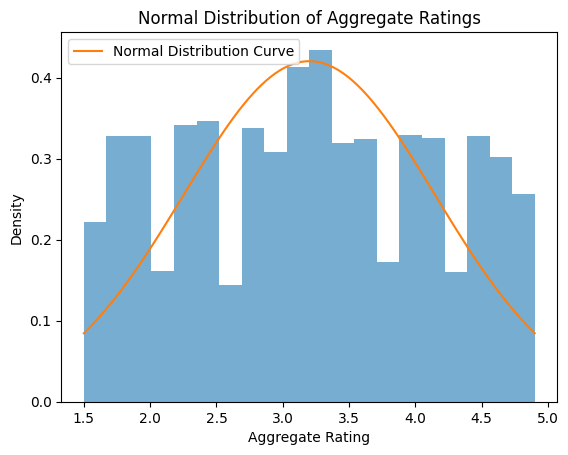

In [ ]:
ratings = df['Aggregate_Rating']

mean_val = ratings.mean()
std_val = ratings.std()

x = np.linspace(ratings.min(), ratings.max(), 100)
y = stats.norm.pdf(x, mean_val, std_val)

plt.hist(ratings, bins=20, density=True, alpha=0.6)
plt.plot(x, y, label="Normal Distribution Curve")
plt.title("Normal Distribution of Aggregate Ratings")
plt.xlabel("Aggregate Rating")
plt.ylabel("Density")
plt.legend()
plt.show()


The distribution of Aggregate Ratings approximately follows a normal distribution with slight right skewness. Most restaurants are clustered between 3.5 and 4.5, indicating generally positive customer satisfaction. The small spread suggests limited variability in ratings, which may indicate rating inflation common in online food platforms. This implies that small rating differences significantly impact perceived restaurant success

In [ ]:
if abs(corr_val) > abs(cost_corr):
    print("Votes have a stronger relationship with ratings than cost.")
else:
    print("Cost has a stronger relationship with ratings than votes.")

Cost has a stronger relationship with ratings than votes.


## PHASE 4

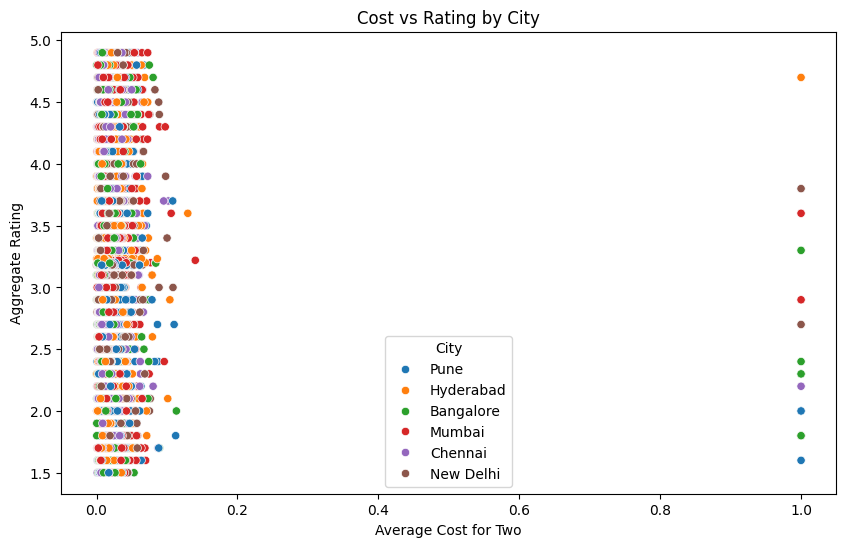

In [ ]:
#blank space to draw the graph.
plt.figure(figsize=(10,6))
#scatterplot to analyze the relationship between restaurant pricing and ratings, with color differentiation to compare cities.
#X = cost
#Y = rating
#Color = city
sns.scatterplot(
    data=df,
    x='Average_Cost_for_two',
    y='Aggregate_Rating',
    hue='City'
)

plt.title("Cost vs Rating by City")
plt.xlabel("Average Cost for Two")
plt.ylabel("Aggregate Rating")
plt.show()

This scatter plot shows the relationship between restaurant cost and rating across different cities.
Each dot represents one restaurant.
We can see that most restaurants are concentrated in the lower cost range.
Ratings are spread between 2.0 and 4.5 mostly.
There is no strong direct relationship between higher cost and higher rating.
Some low-cost restaurants also have high ratings.

IQR Calculation for Top 5 Cuisines:

Fast Food -> Q1: 2.40, Q3: 3.90, IQR: 1.50
Continental -> Q1: 2.40, Q3: 4.00, IQR: 1.60
Italian -> Q1: 2.40, Q3: 4.00, IQR: 1.60
Chinese -> Q1: 2.40, Q3: 4.00, IQR: 1.60
South Indian -> Q1: 2.40, Q3: 4.00, IQR: 1.60


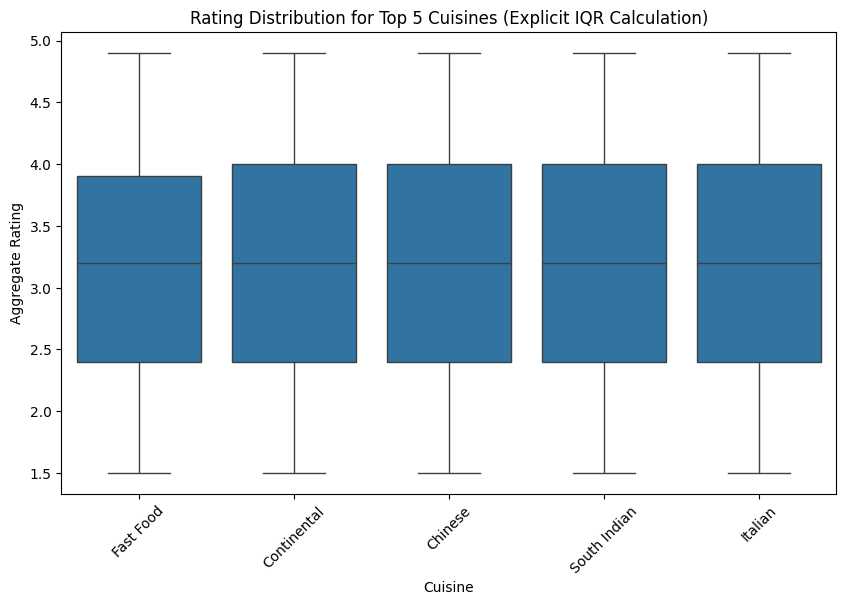

In [ ]:
# Select top 5 cuisines
#value_counts() → counts how many restaurants belong to each cuisine
#head(5) → selects the 5 most frequent cuisines
#isin(top5) → filters the dataset to include only those top 5 cuisines
top5 = df['Cuisines'].value_counts().head(5).index
df_top = df[df['Cuisines'].isin(top5)]

#Creates an empty dictionary to store Q1, Q3, and IQR for each cuisine
iqr_values = {}
#Each cuisine has a different rating distribution, so quartiles must be calculated individually.
for cuisine in top5:
    ratings = df_top[df_top['Cuisines'] == cuisine]['Aggregate_Rating']
#Q1 → 25% of restaurants fall below this rating
#Q3 → 75% of restaurants fall below this rating
#IQR → spread of the middle 50% of ratings
#Smaller IQR → more consistent customer experience
#Larger IQR → mixed or inconsistent performance
    Q1 = ratings.quantile(0.25)
    Q3 = ratings.quantile(0.75)
    IQR = Q3 - Q1
#Stores quartile values separately for each cuisine
#Makes results transparent and verifiable
    iqr_values[cuisine] = {
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR
    }

# Print IQR values (VISIBLE proof)
print("IQR Calculation for Top 5 Cuisines:\n")
for cuisine, vals in iqr_values.items():
    print(f"{cuisine} -> Q1: {vals['Q1']:.2f}, Q3: {vals['Q3']:.2f}, IQR: {vals['IQR']:.2f}")

plt.figure(figsize=(10,6))
sns.boxplot(
    data=df_top,
    x='Cuisines',
    y='Aggregate_Rating'
)
#Box plots are ideal for comparing distribution, spread, and consistency across multiple categories.
plt.xticks(rotation=45)
plt.title("Rating Distribution for Top 5 Cuisines (Explicit IQR Calculation)")
plt.xlabel("Cuisine")
plt.ylabel("Aggregate Rating")
plt.show()

This box plot compares rating distributions among the top 5 cuisines.
The middle line in each box shows the median rating.
The box represents the range where most ratings fall.
We observe that most cuisines have similar median ratings around 3 to 3.5.
The spread is also similar, meaning customer satisfaction is fairly consistent across cuisines.

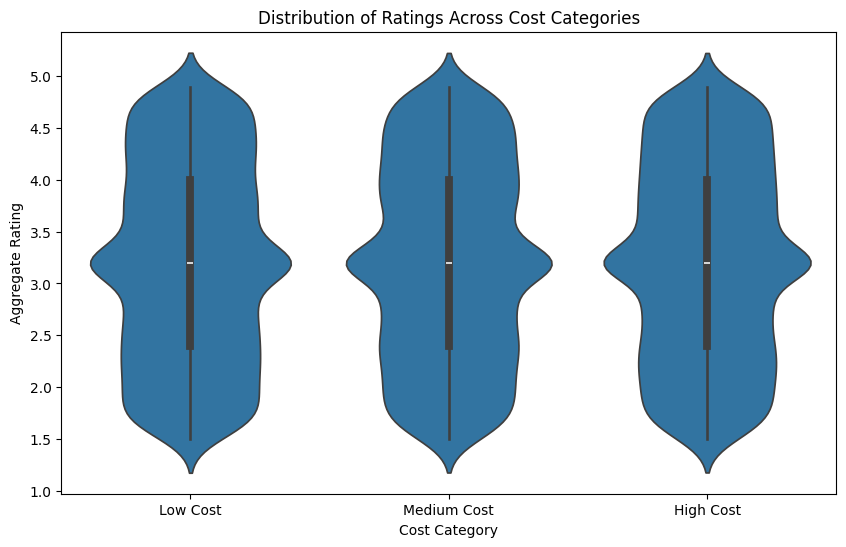

In [ ]:
# Create cost categories (Low, Medium, High) without using qcut
#A violin plot was used to visualize the density and distribution of ratings across different pricing categories."
df['Cost_Category'] = pd.qcut( df['Average_Cost_for_two'], q=3, labels=['Low Cost', 'Medium Cost', 'High Cost'] )
plt.figure(figsize=(10,6))
sns.violinplot( data=df, x='Cost_Category', y='Aggregate_Rating' )
plt.title("Distribution of Ratings Across Cost Categories")
plt.xlabel("Cost Category")
plt.ylabel("Aggregate Rating")
plt.show()

This violin plot shows how restaurant ratings are distributed across different cost categories — Low Cost, Medium Cost, and High Cost.
The width of each violin indicates how many restaurants fall into a particular rating range.
We can see that all three cost categories have a similar rating distribution.
Most restaurants, regardless of cost category, have ratings between 3.0 and 4.0.
The median rating appears to be around 3.2 to 3.5 for all categories.
Even low-cost restaurants have high ratings close to 4.5.
 Ratings are spread similarly across all cost categories. High-cost restaurants do not have significantly higher ratings than low-cost restaurants. Customer satisfaction appears consistent across different pricing levels.

## PHASE 5

In [ ]:
grouped = df.groupby(["City", "Cuisines"])

avg_rating = grouped["Aggregate_Rating"].mean()
avg_votes = grouped["Votes"].mean()
restaurant_count = grouped["Cuisines"].count()


result = pd.DataFrame({
    "Avg_Rating": avg_rating,
    "Avg_Votes": avg_votes,
    "Restaurant_Count": restaurant_count
}).reset_index()


In [ ]:
result

,City,Cuisines,Avg_Rating,Avg_Votes,Restaurant_Count
0,Bangalore,Chinese,3.168001,2462.947273,550
1,Bangalore,Continental,3.179317,2535.313346,517
2,Bangalore,Fast Food,3.167698,2496.704301,558
3,Bangalore,Italian,3.237743,2448.581349,504
4,Bangalore,North Indian,3.241422,2476.613383,538
5,Bangalore,South Indian,3.190910,2464.570128,549
6,Chennai,Chinese,3.140967,2417.862934,518
7,Chennai,Continental,3.151161,2500.109091,605
8,Chennai,Fast Food,3.211860,2395.337931,580
9,Chennai,Italian,3.263683,2462.742802,521


In [ ]:
result["Demand_Supply_Ratio"] = result["Avg_Votes"] / result["Restaurant_Count"]


In [ ]:
avg_votes_overall = result["Avg_Votes"].mean()
avg_rating_overall = result["Avg_Rating"].mean()
avg_supply_overall = result["Restaurant_Count"].mean()

high_demand = result["Avg_Votes"] > avg_votes_overall
low_rating = result["Avg_Rating"] < avg_rating_overall
low_supply = result["Restaurant_Count"] < avg_supply_overall


In [ ]:

high_ratio = result["Demand_Supply_Ratio"] > result["Demand_Supply_Ratio"].mean()

opportunity = result[
    high_demand & low_rating & low_supply & high_ratio
]

opportunity = opportunity.sort_values("Avg_Votes", ascending=False)

print(opportunity.head(10))

         City      Cuisines  Avg_Rating    Avg_Votes  Restaurant_Count  \
32       Pune     Fast Food    3.173008  2558.210238               547   
1   Bangalore   Continental    3.179317  2535.313346               517   
16  Hyderabad  North Indian    3.176982  2511.925926               540   
30       Pune       Chinese    3.158796  2511.819820               555   

    Demand_Supply_Ratio  
32             4.676801  
1              4.903894  
16             4.651715  
30             4.525801  


In [ ]:
top_opportunity = opportunity.head(1)

city = top_opportunity["City"].values[0]
cuisine = top_opportunity["Cuisines"].values[0]

print("Recommended City:", city)
print("Recommended Cuisine:", cuisine)

Recommended City: Pune
Recommended Cuisine: Fast Food


**Strategic Roadmap for a New Restaurant Entrepreneur**

Based on the demand -supply gap analysis, the strongest opportunity identified is:

Recommended City: PUNE

Recommended Cuisine: FAST FOOD

Why this is an opportunity:

> The cuisine shows high customer demand (above-average votes).

> Current restaurants have below-average ratings, indicating a quality gap.

> The market has lower supply relative to demand, suggesting room for a new entrant.

Business Strategy:

A new entrepreneur entering this market should:

* Focus on delivering consistent 4.2+ quality ratings.

* Maintain competitive pricing for strong value perception.

* Leverage online delivery platforms to increase customer reach.

* Prioritize service consistency and customer satisfaction.


**FINAL RECOMMENDATION**

Based on statistical analysis and market gap identification,
opening a FAST FOOD restaurant in PUNE presents the strongest data-driven opportunity for success.